## 1. Setup and Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# Premium graphical configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

# Modern custom palette
modern_palette = ["#2B2D42", "#3A86C8", "#4E9F3D", "#FAB733", "#FF6B6B", "#8D99AE"]
sns.set_palette(sns.color_palette(modern_palette))

# Loading the data
file_path = "Database_STATA_EN/Database_ENG.dta"
try:
    df = pd.read_stata(file_path)
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
except Exception as e:
    print(f"Error: {e}")


Dataset loaded: 4862 rows, 219 columns.


## 2. Target Engineering and Data Leakage Prevention


In [2]:
# 1. Construction of the target (Fintech Adoption Index and binary version)
qp8_cols = ['qp8_1', 'qp8_2', 'qp8_3', 'qp8_4', 'qp8_5']
qp9_cols = ['qp9_1', 'qp9_3', 'qp9_4', 'qp9_5', 'qp9_6', 'qp9_7']

qp8_score = df[qp8_cols].apply(lambda x: (x == 1).astype(int)).sum(axis=1)
def map_qp9_freq(x):
    return x.apply(lambda val: val - 1 if val in [1, 2, 3, 4] else 0)

qp9_mapped = df[qp9_cols].apply(map_qp9_freq)
qp9_score = qp9_mapped.sum(axis=1)

df['fintech_adoption'] = qp8_score + qp9_score
median_fai = df['fintech_adoption'].median()
df['high_adoption'] = (df['fintech_adoption'] > median_fai).astype(int)

print(f"Median Fintech Adoption Index (FAI): {median_fai}")
print("Target class balance (high_adoption):")
print(df['high_adoption'].value_counts(normalize=True))

# 2. Exclusion of target-correlated variables to prevent data leakage
exclude_cols = qp8_cols + qp9_cols + ['fintech_adoption', 'high_adoption', 'wght']
exclude_cols += [c for c in df.columns if c.startswith('qp8_') or c.startswith('qp9_')]

candidate_features = [c for c in df.columns if c not in exclude_cols]
print(f"\nNumber of initial candidate features: {len(candidate_features)}")


Median Fintech Adoption Index (FAI): 6.0
Target class balance (high_adoption):
high_adoption
0    0.511929
1    0.488071
Name: proportion, dtype: float64

Number of initial candidate features: 206


## 3. Data Preprocessing Pipeline


In [3]:
X_raw = df[candidate_features].copy()
y = df['high_adoption']

# 1. Conversion of missing codes to NaN
missing_codes = [-99, -98, -97, -999, -99.0, -98.0, -97.0, -999.0]
for code in missing_codes:
    X_raw = X_raw.replace(code, np.nan)

# 2. Removal of columns with >30% missing data
missing_pct = X_raw.isnull().mean()
features_to_keep = missing_pct[missing_pct <= 0.3].index.tolist()
X_filtered = X_raw[features_to_keep]

print(f"Features after missing values filter (>30%): {len(features_to_keep)} (removed {len(candidate_features) - len(features_to_keep)})")

# 3. Split into Train and Test Set (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

# 4. Imputation of missing values based on Train set median
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=features_to_keep)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features_to_keep)

# 5. Feature Standardization
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=features_to_keep)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=features_to_keep)

print("Data preprocessing completed successfully!")


Features after missing values filter (>30%): 140 (removed 66)
Data preprocessing completed successfully!


## 4. Feature Selection


Features after variance filter: 137 (removed 3)


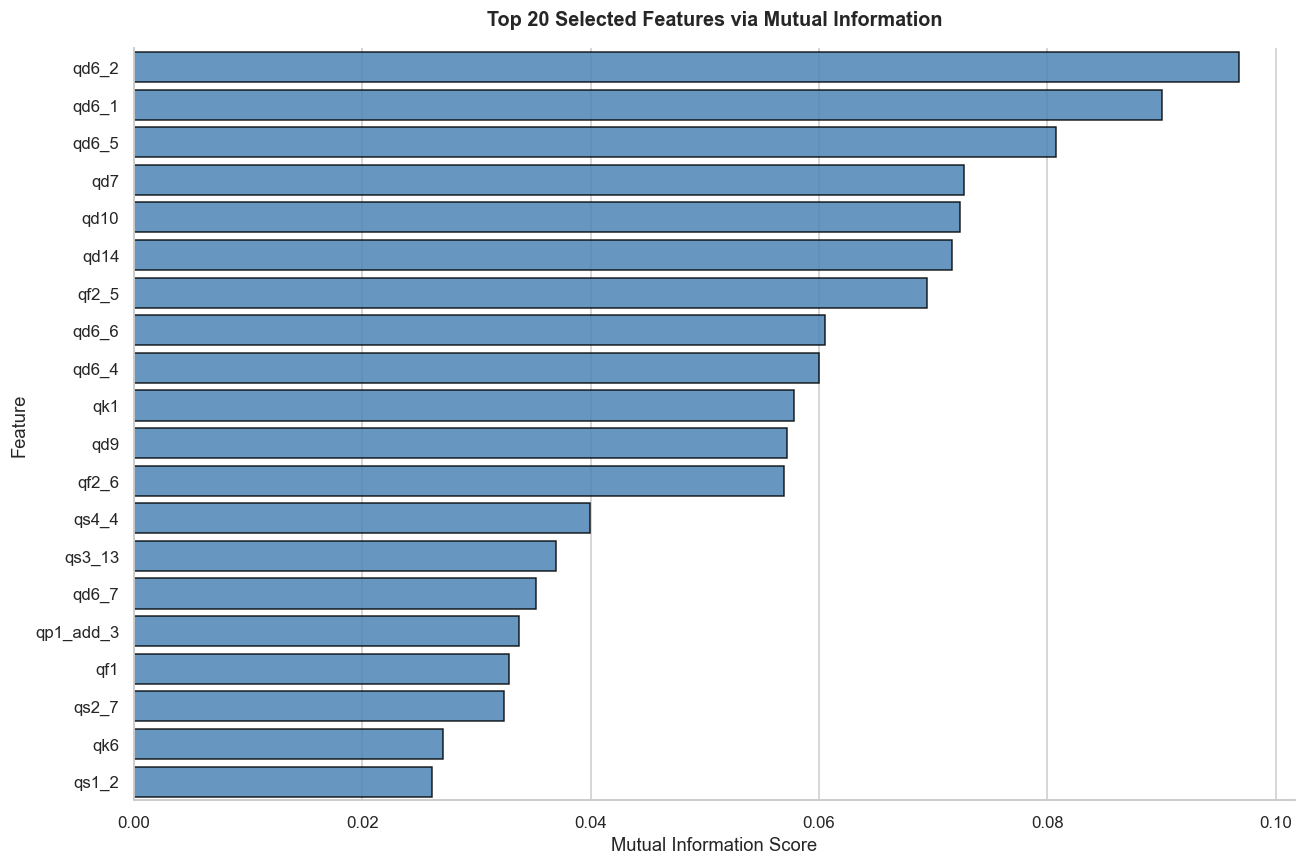

--- Legend of Selected Top 20 Features ---
  qd6_2: Sending or receiving emails (qd6_2) | (univariate p-value: 2.255e-138)
  qd6_1: Using a PC for word processing (qd6_1) | (univariate p-value: 7.717e-128)
  qd6_5: Participating in social networks (qd6_5) | (univariate p-value: 2.588e-104)
  qd7: Respondent age (qd7) | (univariate p-value: 4.596e-31)
  qd10: Primary employment status (qd10) | (univariate p-value: 2.064e-119)
  qd14: Access to internet (qd14) | (univariate p-value: 7.686e-82)
  qf2_5: Using budgeting apps (qf2_5) | (univariate p-value: 3.756e-110)
  qd6_6: Using instant messaging (qd6_6) | (univariate p-value: 4.161e-72)
  qd6_4: Making audio/video calls online (qd6_4) | (univariate p-value: 1.479e-94)
  qk1: Self-assessed financial knowledge (qk1) | (univariate p-value: 8.200e-86)
  qd9: Highest educational attainment (qd9) | (univariate p-value: 3.975e-81)
  qf2_6: Setting up automatic payments (qf2_6) | (univariate p-value: 9.419e-92)
  qs4_4: Trust in fintech apps (

In [4]:
# 1. Variance filter (removal of near-constant columns)
selector = VarianceThreshold(threshold=0.05)
selector.fit(X_train_scaled)
features_var = X_train_scaled.columns[selector.get_support()].tolist()

X_train_var = X_train_scaled[features_var]
X_test_var = X_test_scaled[features_var]
print(f"Features after variance filter: {len(features_var)} (removed {len(features_to_keep) - len(features_var)})")

# 2. K-Best selection using Mutual Information and Univariate p-values calculation
mi_scores = mutual_info_classif(X_train_var, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=features_var).sort_values(ascending=False)

# Calculation of univariate p-values using ANOVA F-test
_, p_values = f_classif(X_train_var, y_train)
p_series = pd.Series(p_values, index=features_var)

# Visualization and selection of top 20
top_features = mi_series.head(20).index.tolist()

plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series.head(20).values, y=mi_series.head(20).index, color="#3A86C8", edgecolor="black", alpha=0.85)
plt.title("Top 20 Selected Features via Mutual Information", fontsize=13)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Dataset reduced to top 20
X_train_selected = X_train_var[top_features]
X_test_selected = X_test_var[top_features]

# Legend of selected feature names based on official questionnaire
feature_descriptions = {
    'qd6_1': 'Using a PC for word processing (qd6_1)',
    'qd6_2': 'Sending or receiving emails (qd6_2)',
    'qd6_5': 'Participating in social networks (qd6_5)',
    'qd7': 'Respondent age (qd7)',
    'qd10': 'Primary employment status (qd10)',
    'qd9': 'Highest educational attainment (qd9)',
    'qd6_4': 'Making audio/video calls online (qd6_4)',
    'qf2_5': 'Using budgeting apps (qf2_5)',
    'qf2_6': 'Setting up automatic payments (qf2_6)',
    'qd14': 'Access to internet (qd14)',
    'qd6_6': 'Using instant messaging (qd6_6)',
    'qd6_7': 'Reading news online (qd6_7)',
    'qk1': 'Self-assessed financial knowledge (qk1)',
    'qs2_7': 'Checking regulation of online providers (qs2_7)',
    'qs3_13': 'Changing passwords periodically (qs3_13)',
    'qs4_4': 'Trust in fintech apps (qs4_4)',
    'qs1_2': 'Willingness to take financial risks (qs1_2)',
    'qf2_3': 'Setting aside money for bills (qf2_3)',
    'qp1_14': 'Owning a non-bank mobile account (qp1_14)',
    'qf1': 'Household financial decision-maker (qf1)',
    'qk6': 'Compound interest knowledge (qk6)',
    'qp1_add_3': 'Awareness of Buy Now Pay Later (qp1_add_3)'
}

print("--- Legend of Selected Top 20 Features ---")
for f in top_features:
    p_val = p_series[f]
    p_str = f"{p_val:.3e}" if p_val > 0 else "< 1e-300"
    print(f"  {f}: {feature_descriptions.get(f, 'Description not available')} | (univariate p-value: {p_str})")


## 5. Model Training and Optimization


In [5]:
# Initialize classifiers with robust hyperparameters
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42)

# Train models
lr_model.fit(X_train_selected, y_train)
rf_model.fit(X_train_selected, y_train)
gb_model.fit(X_train_selected, y_train)

# Generate class predictions for test set
lr_preds = lr_model.predict(X_test_selected)
rf_preds = rf_model.predict(X_test_selected)
gb_preds = gb_model.predict(X_test_selected)

print("Training and predictions completed successfully!")


Training and predictions completed successfully!


## 6. Performance Comparison and Model Selection


=== LOGISTIC REGRESSION PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       498
           1       0.75      0.81      0.78       475

    accuracy                           0.77       973
   macro avg       0.78      0.77      0.77       973
weighted avg       0.78      0.77      0.77       973

=== RANDOM FOREST PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.84      0.71      0.77       498
           1       0.74      0.86      0.79       475

    accuracy                           0.78       973
   macro avg       0.79      0.78      0.78       973
weighted avg       0.79      0.78      0.78       973

=== GRADIENT BOOSTING PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       498
           1       0.77      0.83      0.80       475

    accuracy                           0.80       973
   macro avg    

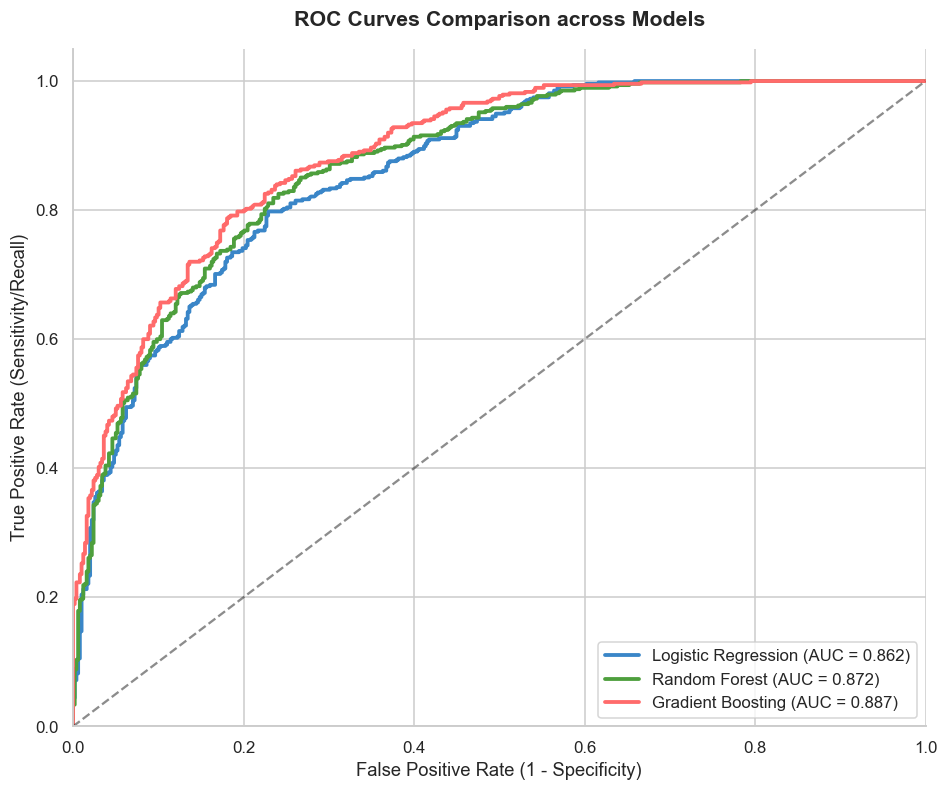

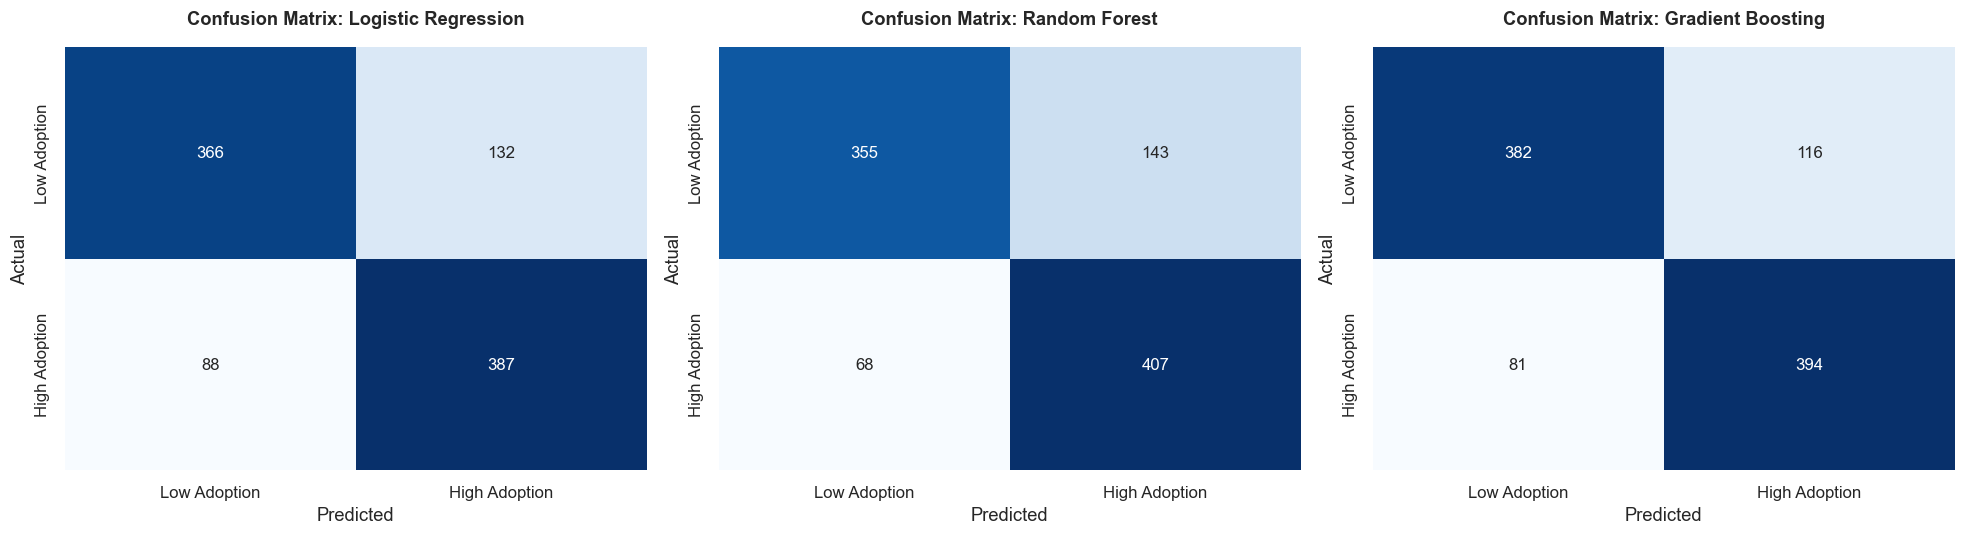

Selected model based on highest AUC: Gradient Boosting (AUC = 0.887)


In [6]:
# 1. Display classification reports
print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(classification_report(y_test, lr_preds))

print("=== RANDOM FOREST PERFORMANCE ===")
print(classification_report(y_test, rf_preds))

print("=== GRADIENT BOOSTING PERFORMANCE ===")
print(classification_report(y_test, gb_preds))

# 2. ROC curves and AUC calculation
lr_probs = lr_model.predict_proba(X_test_selected)[:, 1]
rf_probs = rf_model.predict_proba(X_test_selected)[:, 1]
gb_probs = gb_model.predict_proba(X_test_selected)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)

plt.figure(figsize=(10, 8))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color="#3A86C8", linewidth=2.5)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color="#4E9F3D", linewidth=2.5)
plt.plot(gb_fpr, gb_tpr, label=f'Gradient Boosting (AUC = {gb_auc:.3f})', color="#FF6B6B", linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curves Comparison across Models', fontsize=14, pad=15)
plt.legend(loc="lower right")
plt.show()

# 3. Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
matrices = [  
    (confusion_matrix(y_test, lr_preds), "Logistic Regression"),
    (confusion_matrix(y_test, rf_preds), "Random Forest"),
    (confusion_matrix(y_test, gb_preds), "Gradient Boosting")
]

for idx, (matrix, name) in enumerate(matrices):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=['Low Adoption', 'High Adoption'],
                yticklabels=['Low Adoption', 'High Adoption'])
    axes[idx].set_title(f"Confusion Matrix: {name}", weight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Selected model based on highest AUC
model_aucs = {"Logistic Regression": lr_auc, "Random Forest": rf_auc, "Gradient Boosting": gb_auc}
best_model_name = max(model_aucs, key=model_aucs.get)
print(f"Selected model based on highest AUC: {best_model_name} (AUC = {model_aucs[best_model_name]:.3f})")


## 7. Model Interpretation and Feature Importance


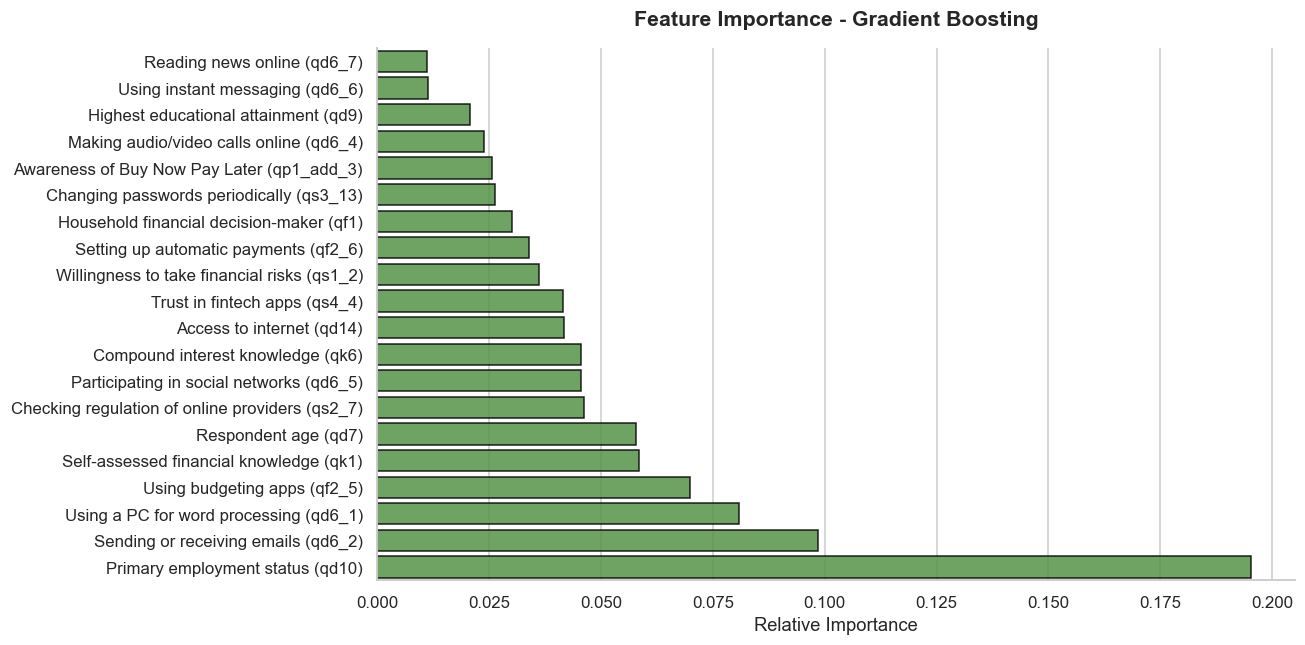

In [7]:
if best_model_name == "Gradient Boosting":
    importances = gb_model.feature_importances_
elif best_model_name == "Random Forest":
    importances = rf_model.feature_importances_
else:
    importances = np.abs(lr_model.coef_[0])

# Map variable codes to their respective descriptive English names
desc_features = [feature_descriptions.get(f, f) for f in top_features]
feat_imp = pd.Series(importances, index=desc_features).sort_values(ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, color="#4E9F3D", edgecolor="black", alpha=0.85)
plt.title(f"Feature Importance - {best_model_name}", fontsize=14, pad=15)
plt.xlabel("Relative Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 8. Multivariate Logistic Regression and Statistical Inference


In [8]:
# statsmodels requires explicit addition of constant term (intercept)
X_train_const = sm.add_constant(X_train_selected)

# Index alignment by resetting y_train index
y_train_aligned = y_train.reset_index(drop=True)

# Fit Logistic Regression model with statsmodels
logit_model_sm = sm.Logit(y_train_aligned, X_train_const)
logit_results = logit_model_sm.fit(maxiter=100)  # maxiter=100 ensures algorithm convergence

# Print statistical summary (including multivariate p-values and coefficients)
print(logit_results.summary())


         Current function value: 0.470709
         Iterations: 100
                           Logit Regression Results                           
Dep. Variable:          high_adoption   No. Observations:                 3889
Model:                          Logit   Df Residuals:                     3868
Method:                           MLE   Df Model:                           20
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                  0.3206
Time:                        18:10:06   Log-Likelihood:                -1830.6
converged:                      False   LL-Null:                       -2694.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1688   1647.564     -0.001      0.999   -3231.334    3226.996
qd6_2         -0.2651      0.070     -3.798      0.000      -0.4